In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import PosteriorManifold, FisherPosteriorManifold
from utils import categorical_entropy

transform = v2.Compose([
    v2.Resize((64, 64), interpolation=v2.InterpolationMode.BILINEAR),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
dataset = torchvision.datasets.MNIST(root='datasets', transform=transform, download=True, train=False)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

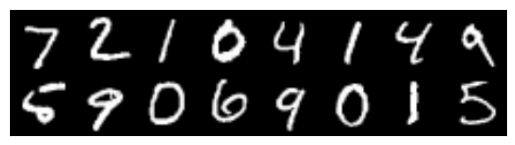

In [2]:
imgs, labels = next(dataloader.__iter__())
seven = imgs[0]
show_img(make_grid(imgs))

## test autoencoder and visualize latent space

### load VAE

/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/repos/torch_vae/model.py:290: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(fname

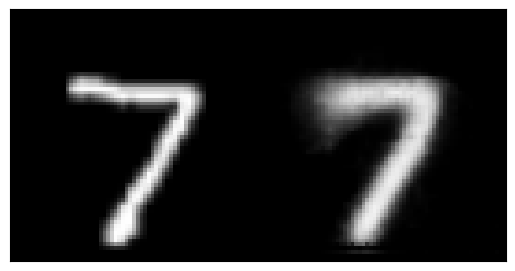

In [7]:
from pretrained_models import MNIST_VAE
vae = MNIST_VAE(n_latent=2)
vae.model.summary = False
with torch.no_grad():
    reconstructed = vae.decode(vae.encode(seven.cuda().unsqueeze(0))).squeeze(0).cpu()
    show_img(make_grid(torch.stack((seven, reconstructed))))

In [8]:
colors = np.array(['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=str(i), markerfacecolor=col) for i, col in enumerate(colors)]

Text(0.5, 1.0, 'MNIST 2D VAE latent space')

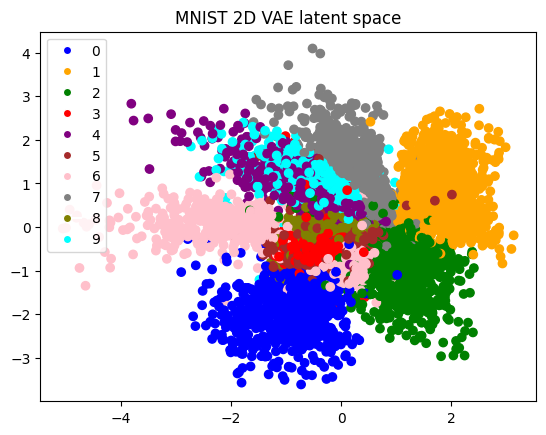

In [ ]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
plt.legend(handles=legend_elements)
plt.title('MNIST 2D VAE latent space')
plt.show()

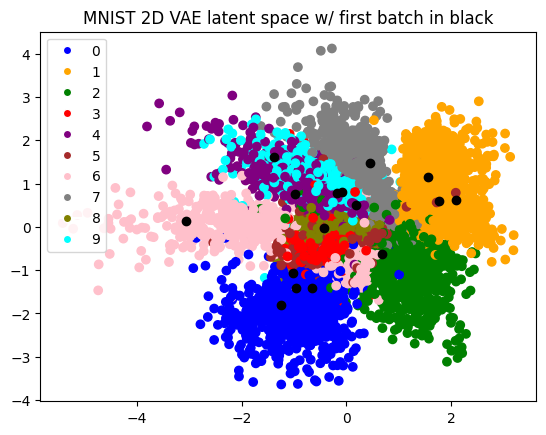

In [44]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.title('MNIST 2D VAE latent space w/ first batch in black')
    imgs_latent = vae.encode(imgs.cuda()).cpu()
    plt.scatter(*imgs_latent.T, c='k')

### linear interpolation and geodesics in latent space

In [6]:
from geometry_tools import *

In [25]:
six, one = imgs[[11, 5]]

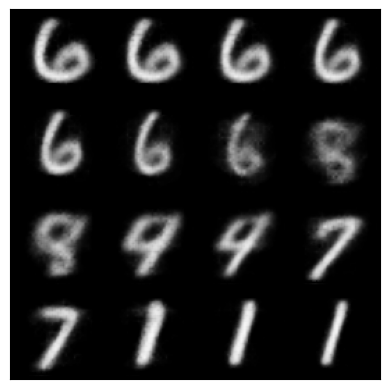

In [26]:
latent_line = lerp(vae.encode(six.unsqueeze(0).cuda()).cpu().squeeze(0), vae.encode(one.unsqueeze(0).cuda()).cpu().squeeze(0), n=16)
latent_line_dec = vae.decode(latent_line.cuda()).cpu()
show_img(make_grid(latent_line_dec, nrow=4))

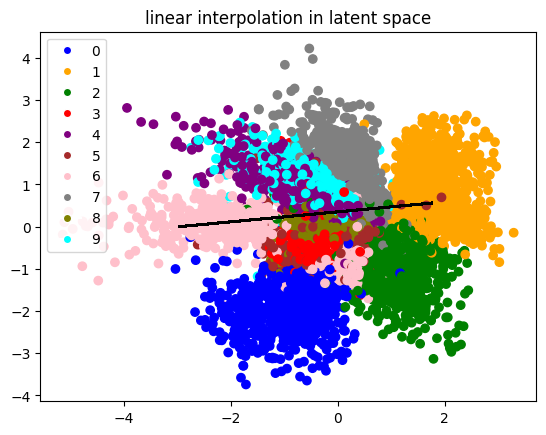

In [59]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.plot(*latent_line.T, c='k')
        plt.title('linear interpolation in latent space')
    

In [11]:
from models.latent_JEM import MLP_ELU_convex
jem = MLP_ELU_convex(2, 8, 10).cuda()
jem.load_state_dict(torch.load('trained_checkpoints/latent_jem.pt'))

/tmp/user/5678/ipykernel_265348/2770806893.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  jem.load_state_dict(torch.load('trained_checkpoints/latent_jem.pt'))


<All keys matched successfully>

In [25]:
jem.logits(vae.encode(imgs.cuda())).argmax(-1)

tensor([7, 2, 1, 0, 4, 1, 9, 9, 8, 4, 0, 6, 9, 0, 1, 0], device='cuda:0')

In [31]:
torch.max(torch.softmax(jem.logits(vae.encode(imgs.cuda())), -1), dim=-1).values

tensor([0.9332, 0.7461, 0.9978, 0.6978, 0.5040, 0.9925, 0.4879, 0.4855, 0.5342,
        0.4877, 0.9264, 0.5352, 0.4616, 0.7304, 0.9980, 0.4558],
       device='cuda:0', grad_fn=<MaxBackward0>)

In [58]:
imgs2 = next(next(dataloader.__iter__()))

TypeError: 'list' object is not an iterator

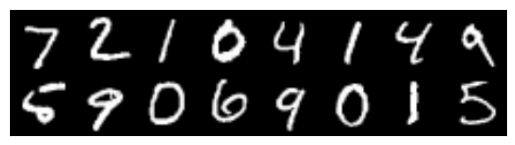

In [26]:
show_img(make_grid(imgs))

In [ ]:
jem_posterior = lambda x: torch.softmax(jem.logits(x), dim=-1)

In [ ]:
geodesic = optimize_geodesic(latent_line.detach(), jem_posterior, n_subdiv=15, n_iter=30000)

optimizing geodesic:   0%|          | 0/30000 [00:00<?, ?it/s, loss=0.148]

optimizing geodesic: 100%|██████████| 30000/30000 [02:24<00:00, 207.03it/s, loss=0.0407]


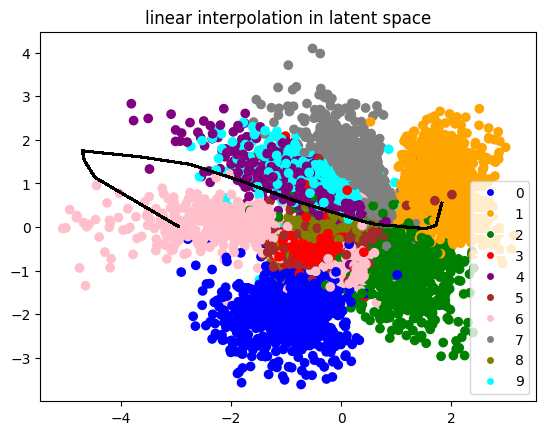

In [ ]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.plot(*geodesic.T, c='k')
        plt.title('linear interpolation in latent space')

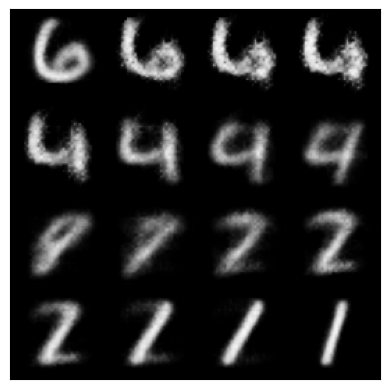

In [57]:
geodesic_dec = vae.decode(geodesic.cuda()).cpu()
show_img(make_grid(geodesic_dec, nrow=4))

In [14]:
itr = dataloader.__iter__()
next(itr)
next(itr)
# next(itr)
imgs2, labels2 = next(itr)

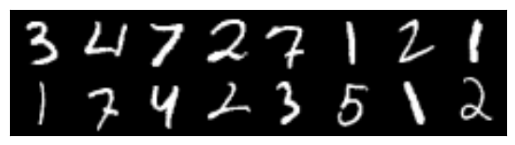

In [15]:
show_img(make_grid(imgs2))

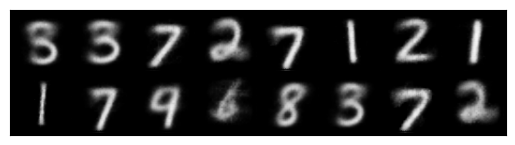

In [ ]:
with torch.no_grad():
    show_img(make_grid(vae.decode(vae.encode(imgs2.cuda())).cpu()))

In [30]:
labels2

tensor([3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2])

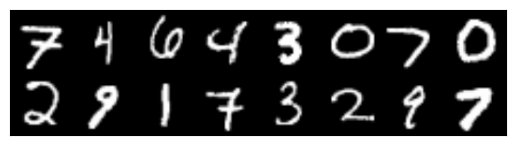

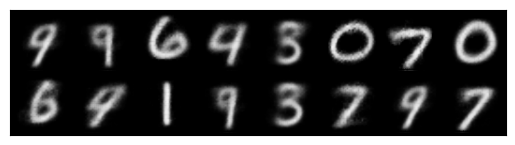

In [21]:
itr = dataloader.__iter__()
next(itr)
next(itr)
next(itr)
next(itr)
imgs3, labels3 = next(itr)
show_img(make_grid(imgs3))
with torch.no_grad():
    show_img(make_grid(vae.decode(vae.encode(imgs3.cuda())).cpu()))

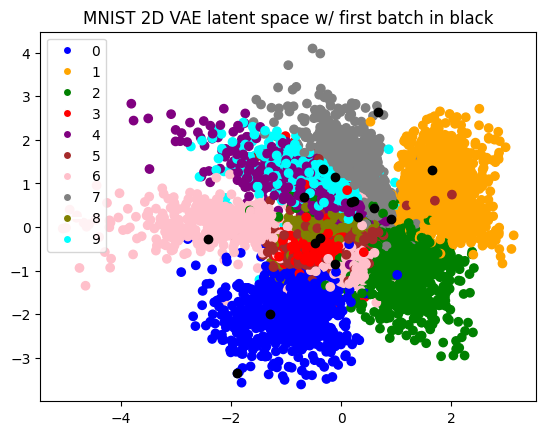

In [35]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
    plt.legend(handles=legend_elements)
    plt.title('MNIST 2D VAE latent space w/ first batch in black')
    imgs_latent = vae.encode(imgs3.cuda()).cpu()
    plt.scatter(*imgs_latent.T, c='k')

In [38]:
vae.encode(imgs3[[7]].cuda()).cpu()

tensor([[-1.3004, -1.9957]], grad_fn=<ToCopyBackward0>)

In [67]:
one, eight = imgs2[[9, 13]]

In [13]:
zero, seven = imgs2[[7, 12]]

In [25]:
seven, four = imgs2[[4, 10]]

In [39]:
zero, six = imgs3[[7, 2]]

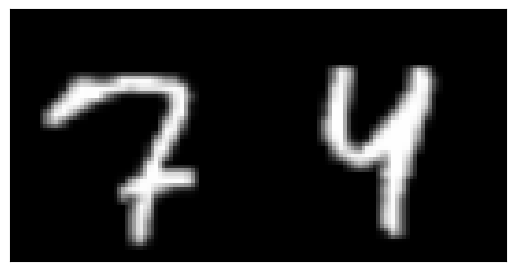

In [26]:
show_img(make_grid(imgs2[[4, 10]]))

In [69]:
latent_line = lerp(vae.encode(one.unsqueeze(0).cuda()).cpu().squeeze(0), vae.encode(eight.unsqueeze(0).cuda()).cpu().squeeze(0), n=16)

## trying geodesics

In [71]:
geodesic = optimize_geodesic(latent_line.detach(), n_subdiv=7)

optimizing geodesic: 100%|██████████| 10000/10000 [00:48<00:00, 206.23it/s, loss=0.0224]


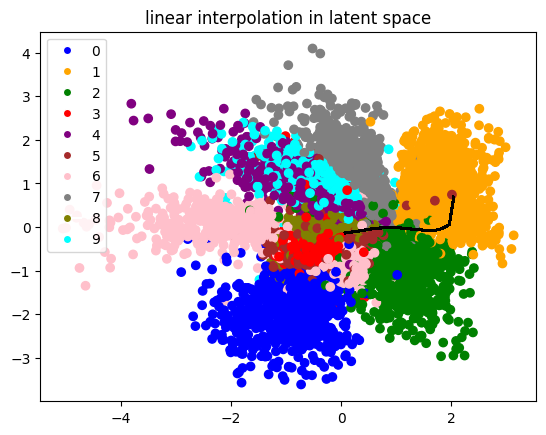

In [72]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.plot(*geodesic.T, c='k')
        plt.title('linear interpolation in latent space')

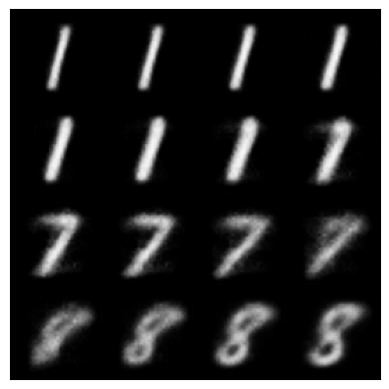

In [73]:
geodesic_dec = vae.decode(latent_line.cuda()).cpu()
show_img(make_grid(geodesic_dec, nrow=4))

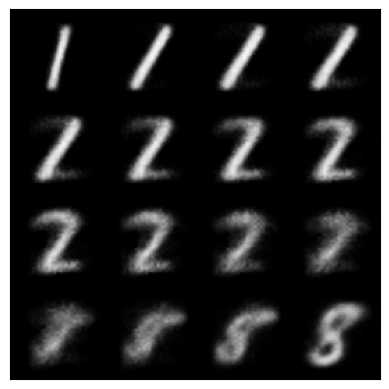

In [74]:
geodesic_dec = vae.decode(geodesic.cuda()).cpu()
show_img(make_grid(geodesic_dec, nrow=4))

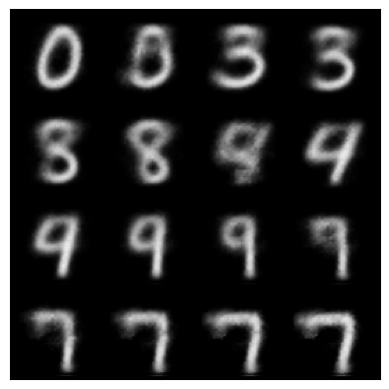

In [78]:
latent_line = lerp(vae.encode(zero.unsqueeze(0).cuda()).cpu().squeeze(0), vae.encode(seven.unsqueeze(0).cuda()).cpu().squeeze(0), n=16)
latent_line_dec = vae.decode(latent_line.cuda()).cpu()
show_img(make_grid(latent_line_dec, nrow=4))

In [79]:
geodesic = optimize_geodesic(latent_line.detach(), n_subdiv=7)

optimizing geodesic: 100%|██████████| 10000/10000 [00:49<00:00, 202.18it/s, loss=0.0422]


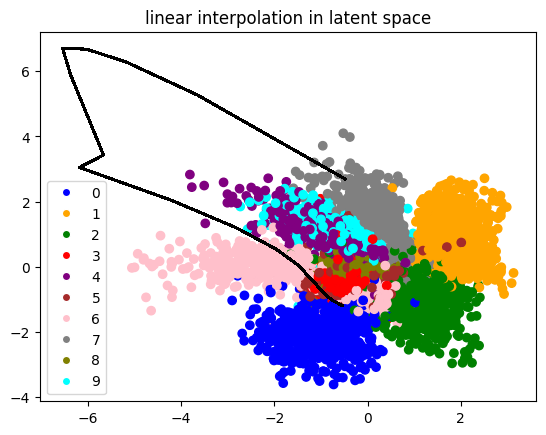

In [82]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.plot(*geodesic.T, c='k')
        plt.title('linear interpolation in latent space')

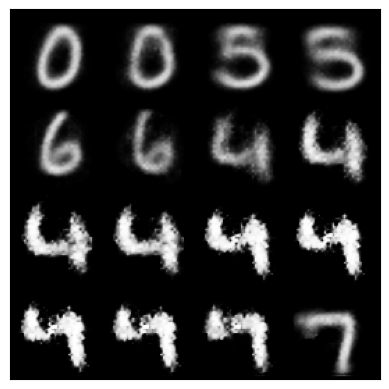

In [81]:
geodesic_dec = vae.decode(geodesic.cuda()).cpu()
show_img(make_grid(geodesic_dec, nrow=4))

## latent gaussian mixture model

In [10]:
gmm = ConditionalGMM(n_dim=2, n_classes=10)
with torch.no_grad():
    for images, class_labels in dataloader:
        gmm.update(vae.encode(images.cuda()), class_labels.cuda())
    gmm.fit()

In [16]:
from posterior_manifold import FisherLogPosteriorManifold
M = FisherLogPosteriorManifold(gmm.log_posterior)

In [11]:
gmm.means

tensor([[-0.8245, -1.7566],
        [ 1.7639,  0.8267],
        [ 1.0564, -0.8484],
        [-0.4180, -0.3990],
        [-0.4916,  0.8623],
        [-0.2331, -0.3179],
        [-1.0686, -0.3726],
        [ 0.3099,  1.2486],
        [-0.2497, -0.0368],
        [-0.3797,  0.8909]], device='cuda:0')

In [12]:
def psd_mat_sqrt(mats: torch.Tensor):
    eigvals, eigvecs = torch.linalg.eigh(mats)
    return torch.einsum('kid, kd, kdj -> kij', eigvecs, torch.sqrt(eigvals), eigvecs.swapaxes(-2, -1))
def unit_circle(resolution: int = 32):
    t = torch.linspace(0, 2*torch.pi, resolution+1)
    return torch.stack((torch.cos(t), torch.sin(t)), dim=-1)
def plot_2d_gmm(means: torch.Tensor, covs: torch.Tensor, scale_fac=1.5, resolution: int=32, color='k'):
    means, covs = means.detach().cpu(), covs.detach().cpu()
    ellipsoids = scale_fac*torch.einsum('kid,rd->irk', psd_mat_sqrt(covs), unit_circle(resolution)) + means.T[:, None, :]
    plt.plot(*ellipsoids, c=color)


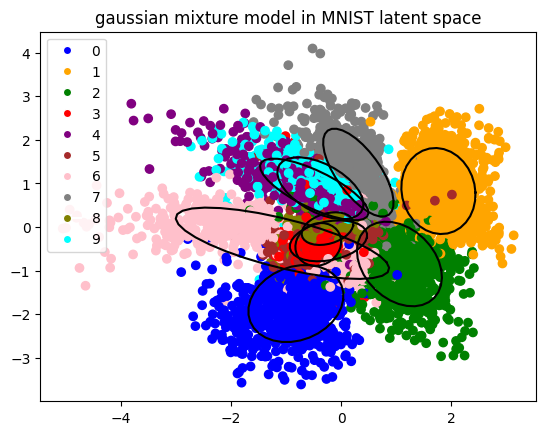

In [13]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
plt.legend(handles=legend_elements)
plt.title('gaussian mixture model in MNIST latent space')
plot_2d_gmm(gmm.means, gmm.covs)

In [52]:
gmm.posterior(vae.encode(imgs.cuda())).argmax(-1)

tensor([7, 2, 1, 0, 4, 1, 9, 4, 8, 4, 0, 6, 9, 0, 1, 0], device='cuda:0')

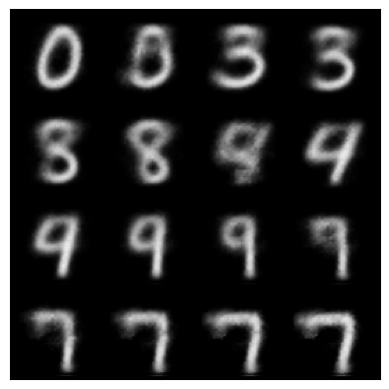

In [19]:
latent_line = lerp(vae.encode(zero.unsqueeze(0).cuda()).cpu().squeeze(0), vae.encode(seven.unsqueeze(0).cuda()).cpu().squeeze(0), n=16)
latent_line_dec = vae.decode(latent_line.cuda()).cpu()
show_img(make_grid(latent_line_dec, nrow=4))

In [20]:
geodesic = optimize_geodesic(latent_line.detach(), n_subdiv=7)

optimizing geodesic: 100%|██████████| 10000/10000 [00:31<00:00, 317.56it/s, loss=0.067]


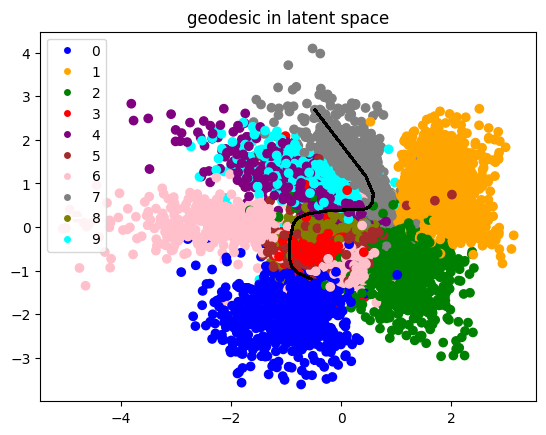

In [23]:
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.plot(*geodesic.T, c='k')
        plt.title('geodesic in latent space')

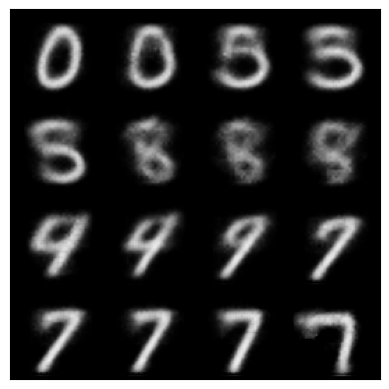

In [24]:
geodesic_dec = vae.decode(geodesic.cuda()).cpu()
show_img(make_grid(geodesic_dec, nrow=4))

optimizing geodesic: 100%|██████████| 10000/10000 [00:32<00:00, 303.53it/s, loss=0.0834]


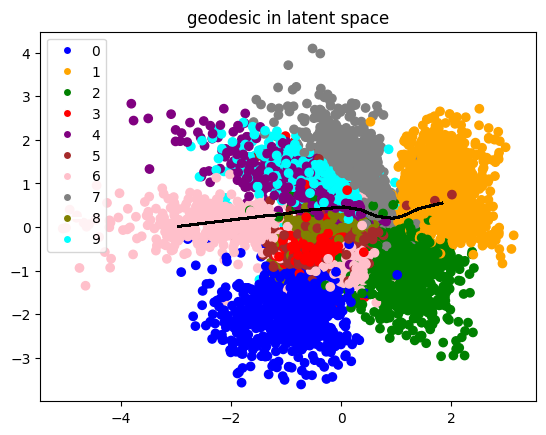

In [ ]:
geodesic = optimize_geodesic(latent_line.detach(), gmm.posterior, n_subdiv=7)
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.plot(*geodesic.T, c='k')
        plt.title('geodesic in latent space')

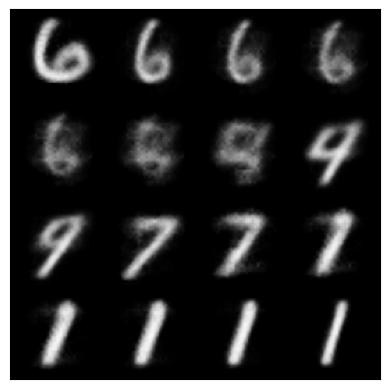

In [28]:
geodesic_dec = vae.decode(geodesic.cuda()).cpu()
show_img(make_grid(geodesic_dec, nrow=4))

In [34]:
with torch.no_grad():
    midp = torch.tensor((0.4, -1.0))
    latent_line = torch.cat((
        lerp(vae.encode(six.unsqueeze(0).cuda()).cpu().squeeze(), midp, 25),
        lerp(midp, vae.encode(one.unsqueeze(0).cuda()).cpu().squeeze(), 25)[1:],
    ))

optimizing geodesic: 100%|██████████| 10000/10000 [00:32<00:00, 310.47it/s, loss=0.0326]


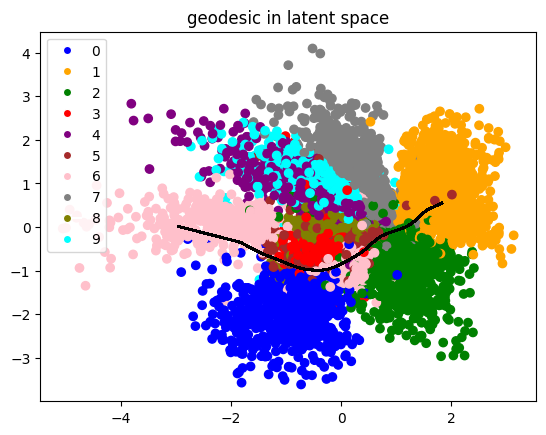

In [ ]:
geodesic = optimize_geodesic(latent_line, gmm.posterior, n_subdiv=7)
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        plt.scatter(*latent.T, c=colors[class_labels.numpy()])
        plt.legend(handles=legend_elements)
        plt.plot(*geodesic.T, c='k')
        plt.title('geodesic in latent space')

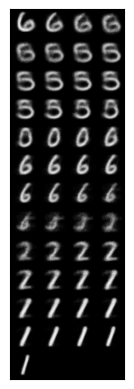

In [36]:
geodesic_dec = vae.decode(geodesic.cuda()).cpu()
show_img(make_grid(geodesic_dec, nrow=4))

In [99]:
def plot_latent_lerp(im1: torch.Tensor, im2: torch.Tensor, n=16):
    latent_line = lerp(vae.encode(im1.unsqueeze(0).cuda()).cpu().squeeze(0), vae.encode(im2.unsqueeze(0).cuda()).cpu().squeeze(0), n=n)
    latent_line_dec = vae.decode(latent_line.cuda()).cpu()
    show_img(make_grid(latent_line_dec, nrow=4))

In [ ]:
def compute_and_plot_gmm_geodesic(im1: torch.Tensor, im2: torch.Tensor, n_curve=16, n_subdiv=7):
    latent_line = lerp(vae.encode(im1.unsqueeze(0).cuda()).cpu().squeeze(0), vae.encode(im2.unsqueeze(0).cuda()).cpu().squeeze(0), n=n_curve)
    geodesic = optimize_geodesic(latent_line.detach(), gmm.posterior, n_subdiv=n_subdiv)
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 6))
    with torch.no_grad():
        for images, class_labels in dataloader:
            latent = vae.encode(images.cuda()).cpu()
            axl.scatter(*latent.T, c=colors[class_labels.numpy()])
        axl.legend(handles=legend_elements)
        axl.plot(*geodesic.T, c='k')
        axl.set_title('geodesic in VAE latent space')
        geodesic_dec = vae.decode(geodesic.cuda()).cpu()
        show_img(make_grid(geodesic_dec, nrow=4), ax=axr)
        axr.set_title('geodesic in data space')
        fig.suptitle('gmm geodesic between two images')

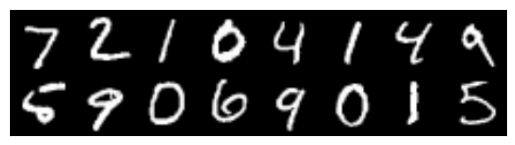

In [54]:
imgs, labels = next(dataloader.__iter__())
seven = imgs[0]
show_img(make_grid(imgs))

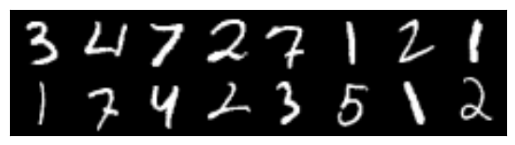

In [86]:
show_img(make_grid(imgs2))

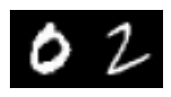

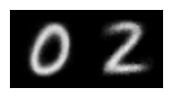

In [17]:
zero, two = imgs[3], imgs2[6]
show_img(make_grid(torch.stack((zero, two))), figsize=(2, 1))
show_img(make_grid(vae.decode(vae.encode(torch.stack((zero, two)).cuda())).cpu()), figsize=(2, 1))

In [22]:
linline = lerp(vae.encode(zero).detach(), vae.encode(two).detach(), n=16)

In [21]:
geodesic = M.optimize_geodesic(vae.encode(zero).detach(), vae.encode(two).detach(), n_subdiv=7)

optimizing geodesic: 100%|██████████| 10000/10000 [00:38<00:00, 258.30it/s, loss=0.148]


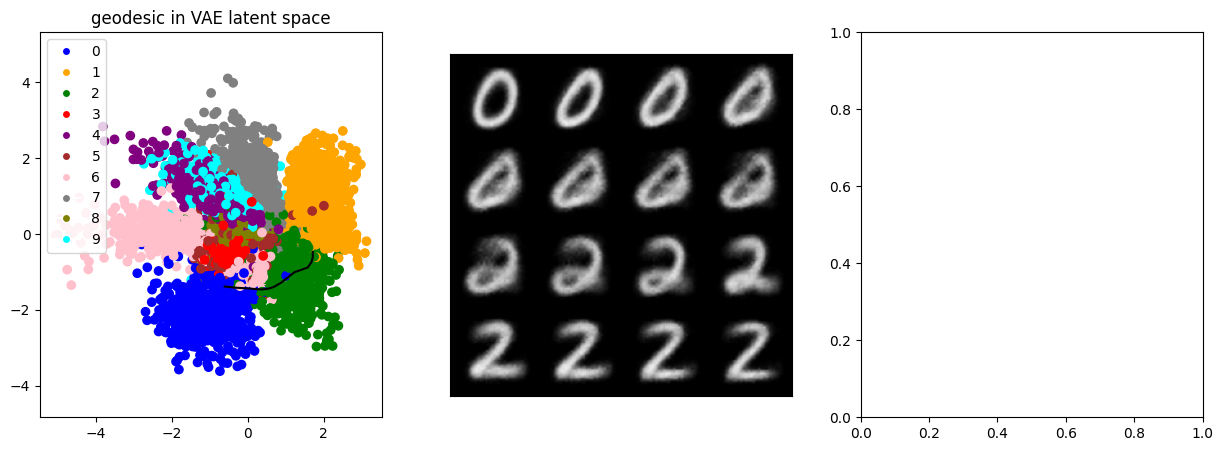

In [29]:
fig, (axl, axm, axr) = plt.subplots(1, 3, figsize=(15, 5))
with torch.no_grad():
    for images, class_labels in dataloader:
        latent = vae.encode(images.cuda()).cpu()
        axl.scatter(*latent.T, c=colors[class_labels.numpy()])
    axl.axis('equal')
    axl.legend(handles=legend_elements)
    axl.plot(*geodesic.T, c='k')
    axl.set_title('geodesic in VAE latent space')
    geodesic_dec = vae.decode(geodesic.cuda()).cpu()
    show_img(make_grid(geodesic_dec, nrow=4), ax=axm)
    # axm.set_title('geodesic in data space')
    # fig.suptitle('$\\bm{g_\\text{ FPP}}$-geodesic between two images')

In [19]:
def compute_and_plot_gmm_geodesic(im1: torch.Tensor, im2: torch.Tensor, n_curve=16, n_subdiv=7):
    latent_line = lerp(vae.encode(im1.unsqueeze(0).cuda()).cpu().squeeze(0), vae.encode(im2.unsqueeze(0).cuda()).cpu().squeeze(0), n=n_curve)
    geodesic = M.optimize_geodesic(vae.encode(im1).detach(), vae.encode(im2).detach(), n_subdiv=n_subdiv)
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(8, 4))
    with torch.no_grad():
        for images, class_labels in dataloader:
            latent = vae.encode(images.cuda()).cpu()
            axl.scatter(*latent.T, c=colors[class_labels.numpy()])
        axl.legend(handles=legend_elements)
        axl.plot(*geodesic.T, c='k')
        axl.set_title('geodesic in VAE latent space')
        geodesic_dec = vae.decode(geodesic.cuda()).cpu()
        show_img(make_grid(geodesic_dec, nrow=4), ax=axr)
        axr.set_title('geodesic in data space')
        fig.suptitle('gmm geodesic between two images')

optimizing geodesic:   0%|          | 0/10000 [00:00<?, ?it/s]

optimizing geodesic: 100%|██████████| 10000/10000 [00:40<00:00, 248.84it/s, loss=0.148]


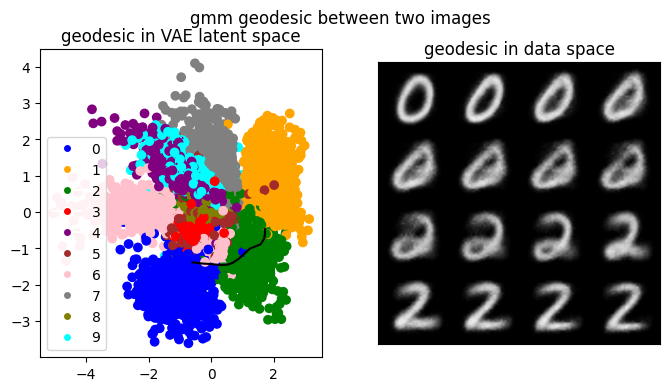

In [20]:
compute_and_plot_gmm_geodesic(zero, two)

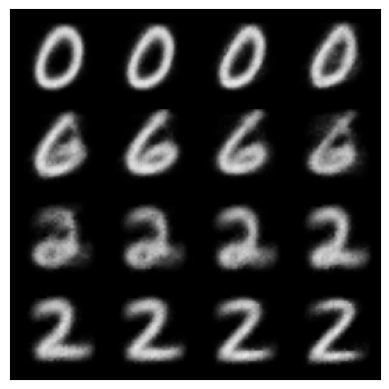

In [100]:
plot_latent_lerp(zero, two)

## computations with new Riemannian Geometry framework

In [10]:
M = PosteriorManifold(gmm.posterior)

In [11]:
def compute_and_plot_gmm_geodesic(im1: torch.Tensor, im2: torch.Tensor, n_curve=16, n_subdiv=7):
    with torch.no_grad():
        latent_im1 = vae.encode(im1.unsqueeze(0).cuda()).cpu().squeeze(0)
        latent_im2 = vae.encode(im2.unsqueeze(0).cuda()).cpu().squeeze(0)
    geodesic = M.optimize_geodesic(latent_im1, latent_im2, n_segments=n_curve, n_subdiv=n_subdiv)
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 6))
    with torch.no_grad():
        for images, class_labels in dataloader:
            latent = vae.encode(images.cuda()).cpu()
            axl.scatter(*latent.T, c=colors[class_labels.numpy()])
        axl.legend(handles=legend_elements)
        axl.plot(*geodesic.T, c='k')
        axl.set_title('geodesic in VAE latent space')
        geodesic_dec = vae.decode(geodesic.cuda()).cpu()
        show_img(make_grid(geodesic_dec, nrow=4), ax=axr)
        axr.set_title('geodesic in data space')
        fig.suptitle('gmm geodesic between two images')

optimizing geodesic: 100%|██████████| 10000/10000 [00:32<00:00, 309.47it/s, loss=0.0278]


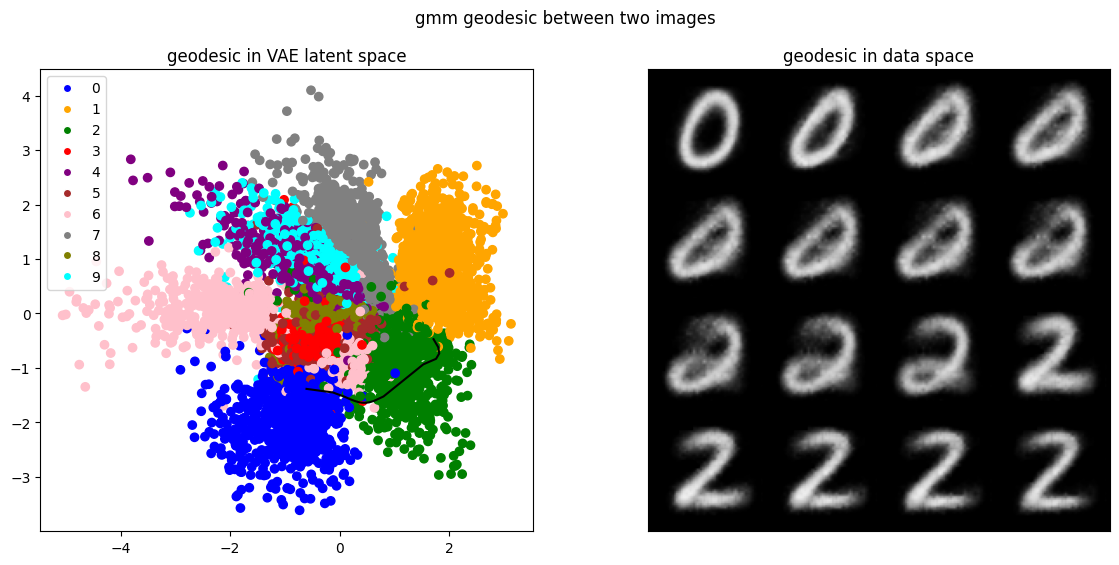

In [12]:
compute_and_plot_gmm_geodesic(zero, two)

### plotting Ricci scalar curvature

In [47]:
xmin, xmax, ymin, ymax = -5.0, 3.0, -3.5, 3.5
X = torch.arange(xmin+0.5, xmax-0.5, 0.05)
Y = torch.arange(ymin+0.5, ymax-0.5, 0.05)
grid = torch.stack(torch.meshgrid(X, Y, indexing='xy')).movedim(0, -1)

In [48]:
ric_grid = M.ric(grid.cuda()).detach().cpu()

In [53]:
ric_grid = torch.clamp(ric_grid, min=-30, max=30)

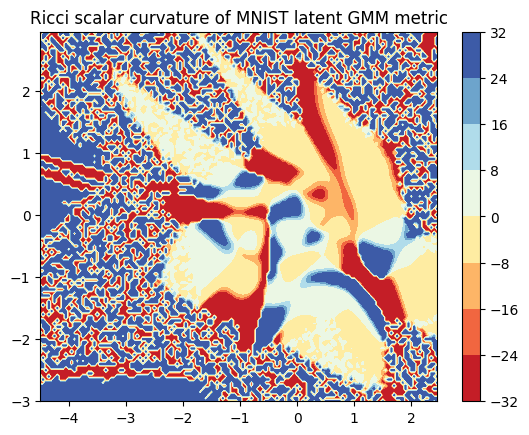

In [56]:
plt.contourf(X, Y, ric_grid, cmap='RdYlBu')
plt.colorbar()
plt.title('Ricci scalar curvature of MNIST latent GMM metric')
plt.show()

## computations with Fisher-Rao information metric

In [7]:
M_FR = FisherPosteriorManifold(gmm.posterior)

In [105]:
def compute_and_plot_gmm_geodesic(im1: torch.Tensor, im2: torch.Tensor, n_curve=16, n_subdiv=7):
    with torch.no_grad():
        latent_im1 = vae.encode(im1.unsqueeze(0).cuda()).cpu().squeeze(0)
        latent_im2 = vae.encode(im2.unsqueeze(0).cuda()).cpu().squeeze(0)
    geodesic = M_FR.optimize_geodesic(latent_im1, latent_im2, n_segments=n_curve, n_subdiv=n_subdiv)
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 6))
    with torch.no_grad():
        for images, class_labels in dataloader:
            latent = vae.encode(images.cuda()).cpu()
            axl.scatter(*latent.T, c=colors[class_labels.numpy()])
        axl.legend(handles=legend_elements)
        axl.plot(*geodesic.T, c='k')
        axl.set_title('geodesic in VAE latent space')
        geodesic_dec = vae.decode(geodesic.cuda()).cpu()
        show_img(make_grid(geodesic_dec, nrow=4), ax=axr)
        axr.set_title('geodesic in data space')
        fig.suptitle('GMM Fisher geodesic between two images')

optimizing geodesic: 100%|██████████| 10000/10000 [00:33<00:00, 300.93it/s, loss=0.151]


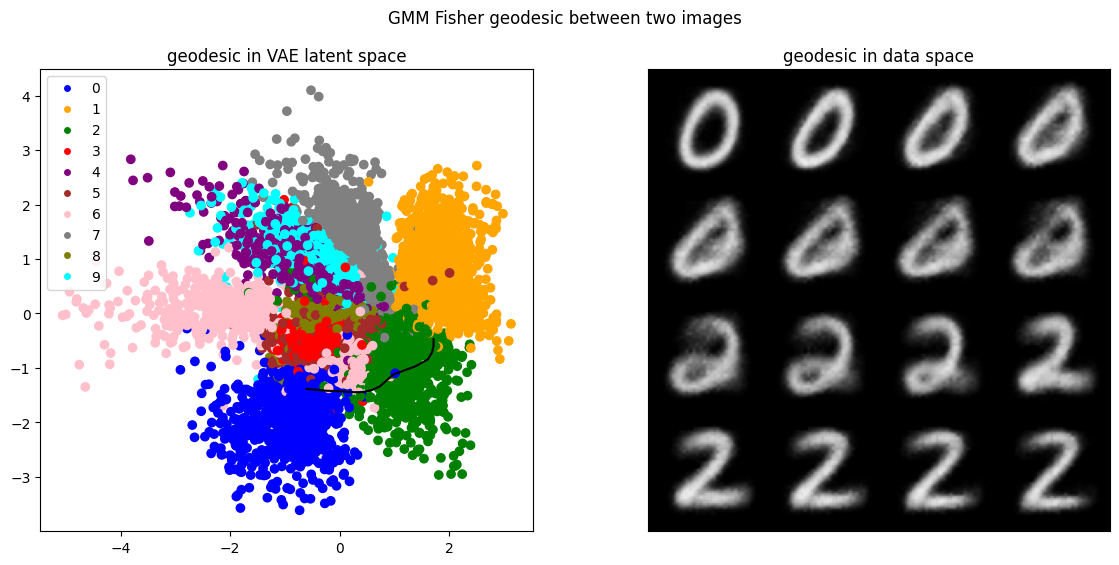

In [14]:
compute_and_plot_gmm_geodesic(zero, two)

In [9]:
xmin, xmax, ymin, ymax = -5.0, 3.0, -3.5, 3.5
X = torch.arange(xmin+0.5, xmax-0.5, 0.05)
Y = torch.arange(ymin+0.5, ymax-0.5, 0.05)
grid = torch.stack(torch.meshgrid(X, Y, indexing='xy')).movedim(0, -1)

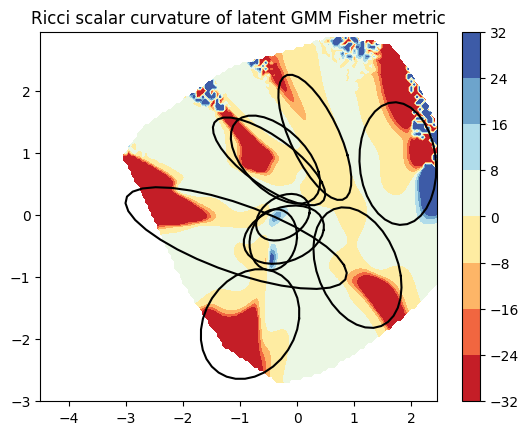

In [12]:
ric_grid = torch.clamp(M_FR.ric(grid.cuda()).detach().cpu(), min=-30, max=30)
plt.contourf(X, Y, ric_grid, cmap='RdYlBu')
plt.colorbar()
plt.title('Ricci scalar curvature of latent GMM Fisher metric')
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()

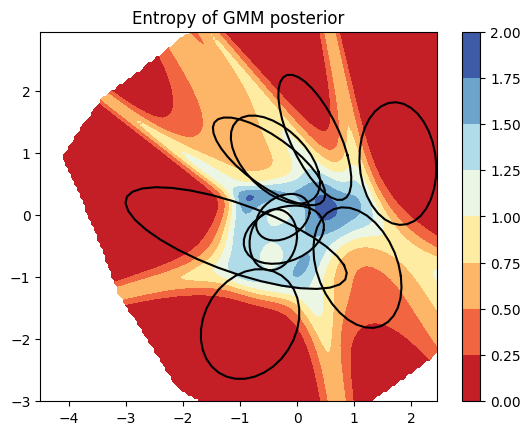

In [16]:
entropy_grid = torch.clamp(categorical_entropy(gmm.posterior(grid.cuda()).detach().cpu()), max=30)
plt.contourf(X, Y, entropy_grid, cmap='RdYlBu')
plt.colorbar()
plt.title('Entropy of GMM posterior')
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()

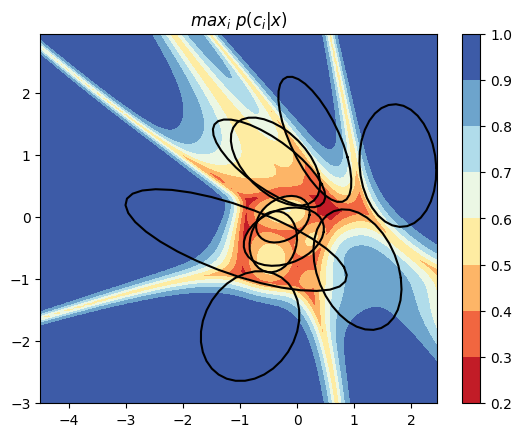

In [20]:
maxprob_grid = torch.max(gmm.posterior(grid.cuda()).detach().cpu(), dim=-1).values
plt.contourf(X, Y, maxprob_grid, cmap='RdYlBu')
plt.colorbar()
plt.title('$max_i$ $p(c_i|x)$')
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()

optimizing geodesic: 100%|██████████| 10000/10000 [00:32<00:00, 303.52it/s, loss=0.068]


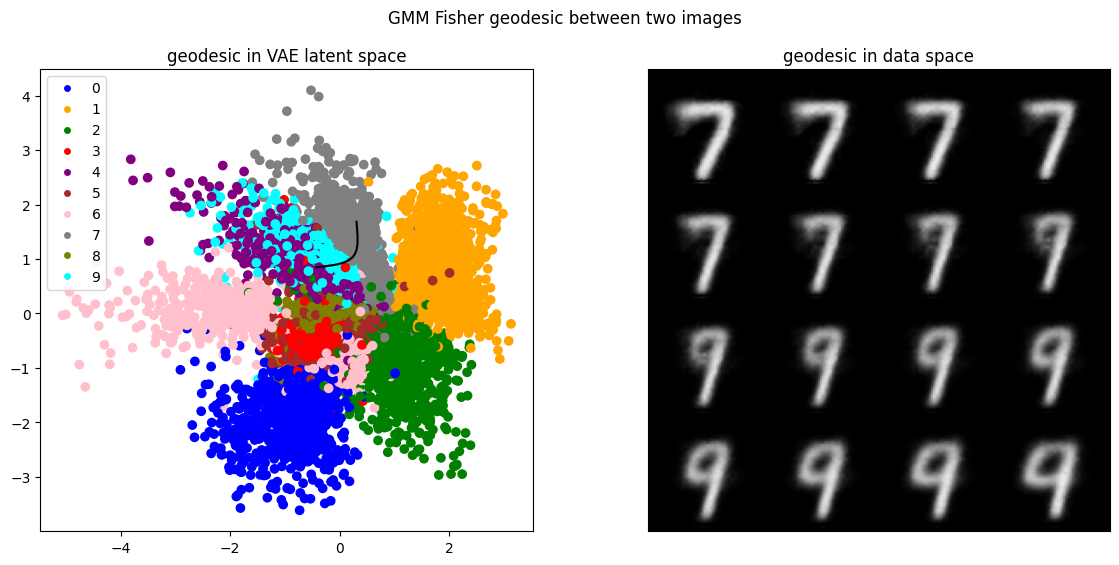

In [28]:
compute_and_plot_gmm_geodesic(seven, four)

optimizing geodesic: 100%|██████████| 10000/10000 [00:33<00:00, 299.84it/s, loss=0.338]


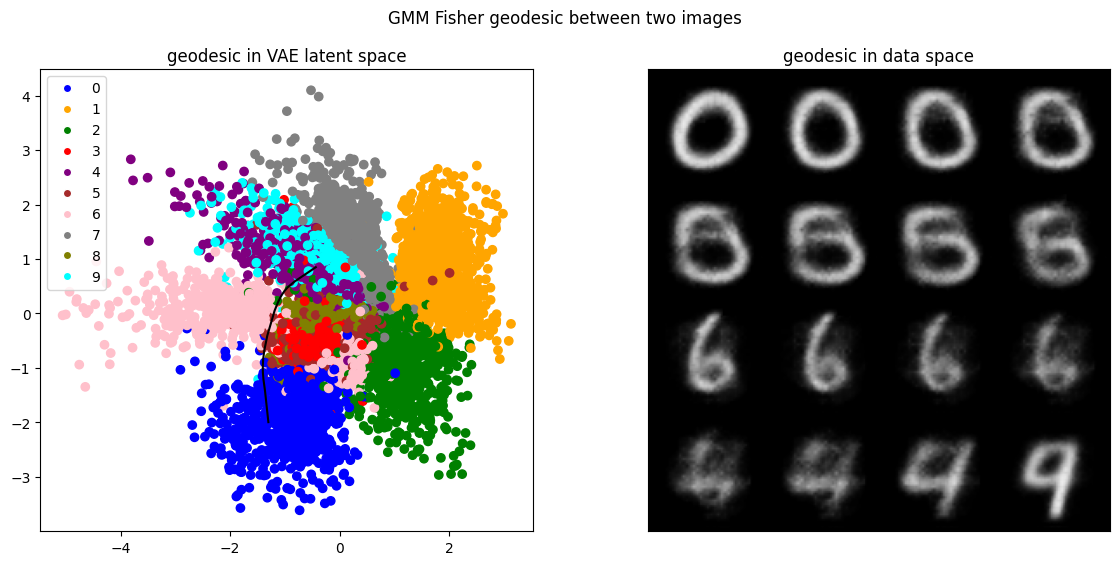

In [43]:
compute_and_plot_gmm_geodesic(zero, four)

In [78]:
def compute_and_plot_gmm_Karcher_mean(*images: torch.Tensor):
    latent_images = [vae.encode(image.unsqueeze(0).cuda())[0] for image in images]
    karcher_mean = M_FR.optimize_Karcher_mean(*latent_images)
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 2.5))
    show_img(make_grid(vae.decode(torch.stack(latent_images)).cpu()), ax=axl)
    axl.set_title('images')
    show_img(vae.decode(karcher_mean.unsqueeze(0)).cpu()[0], ax=axr)
    axr.set_title('Karcher mean')
    

In [57]:
def compute_and_plot_gmm_latent_Karcher_mean(*latent_images: torch.Tensor):
    latent_images = [latent_image.cuda() for latent_image in latent_images] #type:ignore
    karcher_mean = M_FR.optimize_Karcher_mean(*latent_images)
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 2.5), gridspec_kw={'width_ratios': [len(latent_images),1]})
    show_img(make_grid(vae.decode(torch.stack(latent_images)).cpu()), ax=axl)
    axl.set_title('images')
    show_img(vae.decode(karcher_mean.unsqueeze(0)).cpu()[0], ax=axr)
    axr.set_title('Karcher mean')
    

optimizing Karcher mean:   0%|          | 0/10000 [00:00<?, ?it/s, loss=9.63]

optimizing Karcher mean: 100%|██████████| 10000/10000 [01:08<00:00, 145.98it/s, loss=8.56]


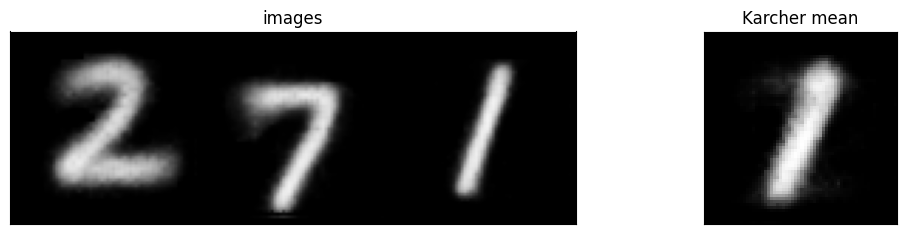

In [58]:
two = torch.tensor(((1.5, -0.8)))
seven = torch.tensor(((0.4, 1.5)))
one = torch.tensor(((1.9, 0.5)))
compute_and_plot_gmm_latent_Karcher_mean(two, seven, one)

In [61]:
from torchvision.datasets import VisionDataset
def get_random_images(dataset: VisionDataset, n=3):
    loader = DataLoader(dataset, batch_size=n, shuffle=True)
    imgs, labels = next(iter(loader))
    return imgs

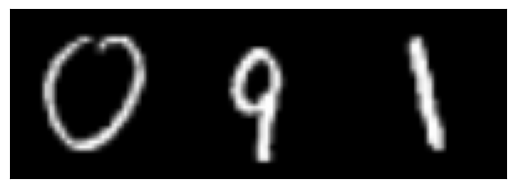

In [74]:
random_imgs = get_random_images(dataset)
show_img(make_grid(random_imgs))

optimizing Karcher mean:   0%|          | 0/10000 [00:00<?, ?it/s, loss=71.5]

optimizing Karcher mean: 100%|██████████| 10000/10000 [01:05<00:00, 151.78it/s, loss=17.5]


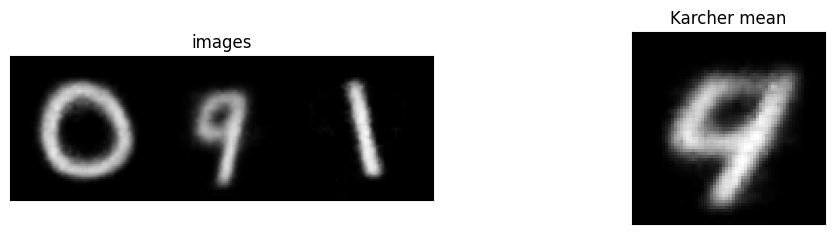

In [79]:
compute_and_plot_gmm_Karcher_mean(*random_imgs)

In [72]:
l1 = vae.encode(random_imgs[[0]].cuda())[0].cpu()
l2 = vae.encode(random_imgs[[1]].cuda())[0].cpu()
l3 = vae.encode(random_imgs[[2]].cuda())[0].cpu()

optimizing Karcher mean: 100%|██████████| 10000/10000 [01:08<00:00, 146.87it/s, loss=12.4]


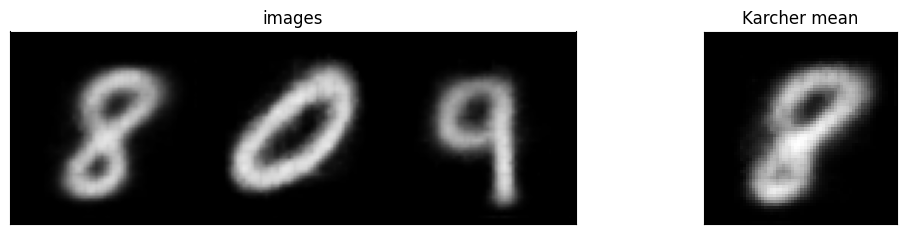

In [73]:
compute_and_plot_gmm_latent_Karcher_mean(l1, l2, l3)

optimizing Karcher mean: 100%|██████████| 10000/10000 [01:19<00:00, 126.21it/s, loss=16.7]


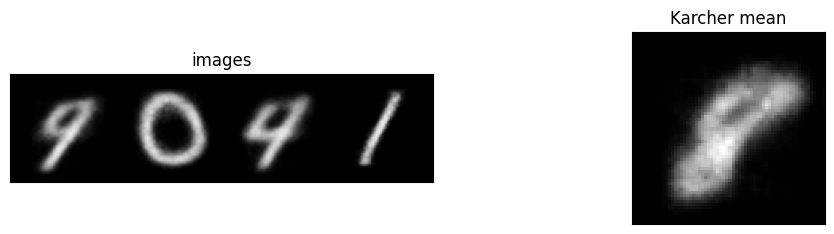

In [80]:
compute_and_plot_gmm_Karcher_mean(*get_random_images(dataset, n=4))

In [81]:
def get_random_image(dataset: VisionDataset):
    loader = DataLoader(dataset, batch_size=2, shuffle=True)
    imgs, _ = next(iter(loader))
    return imgs[0]

### trying to average geometric transformations
(e.g. affine such as translations, scaling, rotations)

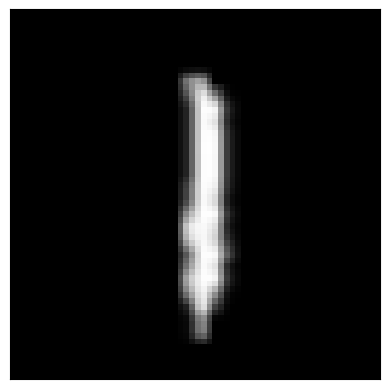

In [97]:
test_img = get_random_image(dataset)
show_img(test_img)

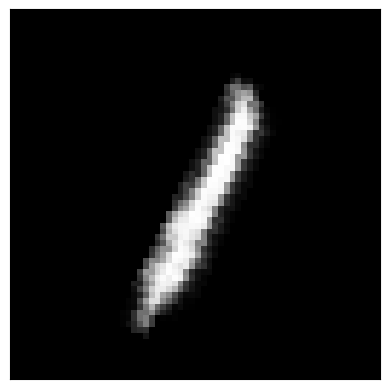

In [103]:
rotated_test_img = v2.functional.rotate(test_img, -25.0)
show_img(rotated_test_img)

optimizing geodesic: 100%|██████████| 10000/10000 [00:33<00:00, 300.34it/s, loss=0.00377]


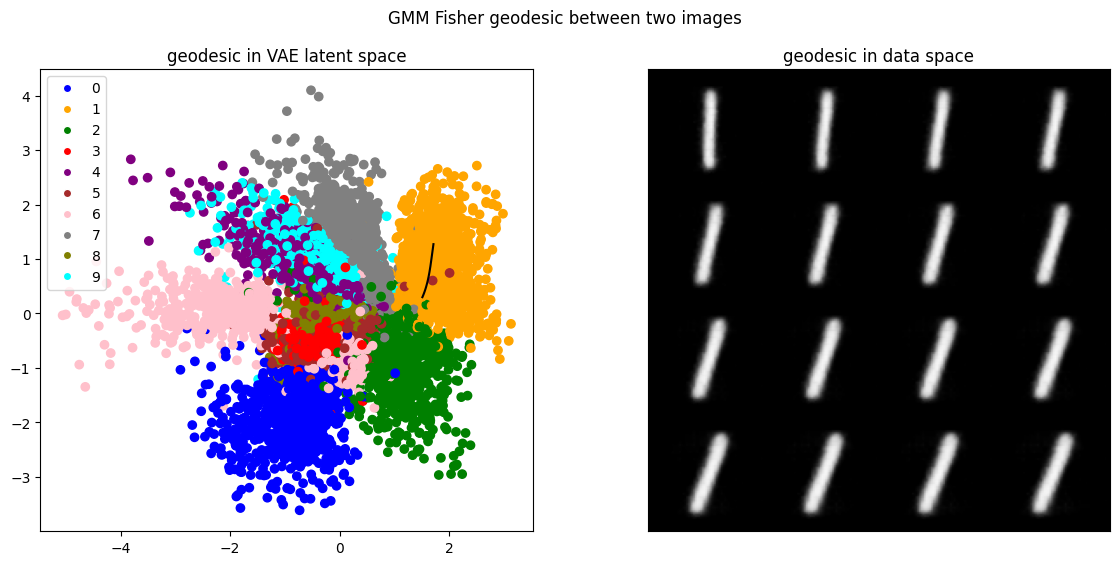

In [106]:
compute_and_plot_gmm_geodesic(test_img, rotated_test_img)

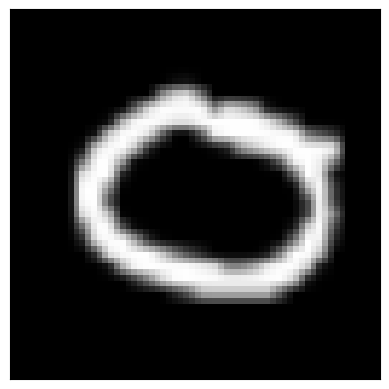

In [141]:
test_img = get_random_image(dataset)
show_img(test_img)

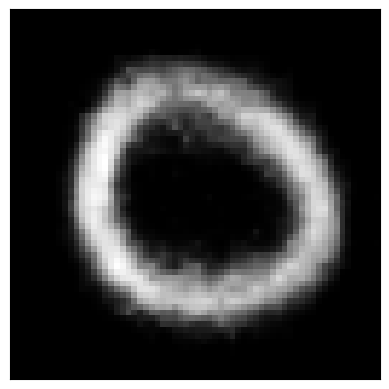

In [144]:
show_img(vae.decode(vae.encode(test_img.unsqueeze(0).cuda())).cpu()[0])

In [ ]:
left_translated_test_img = v2.functional.affine(test_img, angle=0., translate=[-3, 0.], scale=1., shear=[0.])
right_translated_test_img = v2.functional.affine(test_img, angle=0., translate=[3, 0.], scale=1., shear=[0.])

# compute_and_plot_gmm_geodesic(left_translated_test_img, right_translated_test_img)